In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = "saida.csv"  # ajuste o caminho se o saida.csv estiver em outra pasta
df = pd.read_csv(path)

# Nomes de coluna do saida.csv (ver scripts/bag_para_csv.py): filtrada_* é
# a pose estimada (EKF), ground_truth_* é a pose real (Gazebo).
df["Robot_X_est"] = pd.to_numeric(df["filtrada_x"], errors="coerce")
df["Robot_Y_est"] = pd.to_numeric(df["filtrada_y"], errors="coerce")
df["Robot_X_real"] = pd.to_numeric(df["ground_truth_x"], errors="coerce")
df["Robot_Y_real"] = pd.to_numeric(df["ground_truth_y"], errors="coerce")

# Trajetórias (apenas linhas com tudo preenchido)
traj = df.dropna(subset=["Robot_X_est","Robot_Y_est","Robot_X_real","Robot_Y_real"]).copy()


In [ ]:
from dataclasses import dataclass
from typing import Dict, Iterable, Optional, Tuple

@dataclass(frozen=True)
class Anchor:
    x: float
    y: float

# Mesmas posições de worlds/campo_agricola.world / config/ekf_uwb.yaml:
# cada âncora na cabeça da planta correspondente (mesmo x/y da planta).
anchors: Dict[int, Anchor] = {
    0: Anchor(-0.8, -0.5),  # uwb_anchor0
    1: Anchor(-0.4, -0.5),  # uwb_anchor1
    2: Anchor( 0.0, -0.5),  # uwb_anchor2
    3: Anchor( 0.4, -0.5),  # uwb_anchor3
    4: Anchor( 0.8, -0.5),  # uwb_anchor4

    5: Anchor(-0.8,  0.5),  # uwb_anchor5
    6: Anchor(-0.4,  0.5),  # uwb_anchor6
    7: Anchor( 0.0,  0.5),  # uwb_anchor7
    8: Anchor( 0.4,  0.5),  # uwb_anchor8
    9: Anchor( 0.8,  0.5),  # uwb_anchor9
}


In [ ]:
import numpy as np

# O saida.csv não tem mais uma coluna única de "checkpoint atual" nem de
# validade (ver scripts/bag_para_csv.py) — só uma coluna anchorN_range por
# âncora. Aqui o checkpoint de cada linha é derivado como a âncora de
# menor range lida naquele instante, entre as que reportaram.
range_cols = ["anchor%d_range" % i for i in sorted(anchors) if "anchor%d_range" % i in df.columns]
for c in range_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")


def calcula_checkpoint(row):
    valores = {int(c[len("anchor"):-len("_range")]): row[c]
              for c in range_cols if pd.notna(row[c])}
    if not valores:
        return pd.Series({"Checkpoint": np.nan, "Checkpoint_Dist_Sensor": np.nan})
    cid = min(valores, key=valores.get)
    return pd.Series({"Checkpoint": cid, "Checkpoint_Dist_Sensor": valores[cid]})


df[["Checkpoint", "Checkpoint_Dist_Sensor"]] = df.apply(calcula_checkpoint, axis=1)

df["Checkpoint_X"] = df["Checkpoint"].map(lambda cid: anchors[int(cid)].x if pd.notna(cid) else np.nan)
df["Checkpoint_Y"] = df["Checkpoint"].map(lambda cid: anchors[int(cid)].y if pd.notna(cid) else np.nan)

# Distância real = geometria entre a pose real (ground truth) e a posição
# conhecida da âncora — não vem do sensor, serve pra comparar com
# Checkpoint_Dist_Sensor (ambas em metros).
df["Checkpoint_Dist_Real"] = np.sqrt(
    (df["Robot_X_real"] - df["Checkpoint_X"])**2 + (df["Robot_Y_real"] - df["Checkpoint_Y"])**2
)


In [ ]:
plt.figure()

# Estimated (azul)
plt.plot(
    traj["Robot_X_est"].values, traj["Robot_Y_est"].values,
    linestyle="-", linewidth=0.3, marker="o", markersize=1.2,
    color="blue", label="Estimated (PF)"
)

plt.plot(
    traj["Robot_X_real"].to_numpy(),  # 1D
    traj["Robot_Y_real"].to_numpy(),  # 1D
    linestyle="-", linewidth=0.3, marker="o", markersize=1.2,
    color="red", label="Real"
)


cmap = plt.get_cmap("tab10")
colors = {cid: cmap(i % 10) for i, cid in enumerate(anchors.keys())}

for cid in anchors.keys():
    sub = anchors[cid]
    plt.scatter(
        anchors[cid].x, anchors[cid].y,
        marker="x", s=55,
        color=colors[cid],
        # label=f"Checkpoint {cid}"
    )
    # label no ponto (número do checkpoint)

    plt.annotate(
        str(cid),
        (anchors[cid].x, anchors[cid].y),
        textcoords="offset points",
        xytext=(4, 4)
    )

# Pontos com checkpoint identificado (âncora mais próxima naquele
# instante): triângulos com cor por âncora. Não existe mais o conceito de
# "Checkpoint_Valid" no saida.csv, então aqui é toda linha com checkpoint
# derivado, sem filtro de validade.
valid = df.dropna(subset=["Robot_X_est", "Robot_Y_est", "Checkpoint"]).copy()
valid["Checkpoint"] = valid["Checkpoint"].astype(int)

valid_ids = sorted(valid["Checkpoint"].unique().tolist())
for cid in valid_ids:
    sub = valid[valid["Checkpoint"] == cid]
    plt.scatter(
        sub["Robot_X_est"], sub["Robot_Y_est"],
        marker="^", s=35,
        color=colors.get(cid, cmap(0)),
        label=f"Checkpoint {cid}"
    )

plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Evalution [PF]")
plt.axis("equal")
plt.grid(True)

# Legenda fora do gráfico (pra não poluir)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
cols = ["Robot_X_est","Robot_Y_est","Robot_X_real","Robot_Y_real",
        "Checkpoint_Dist_Sensor","Checkpoint_Dist_Real"]
for c in cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Filtrar linhas válidas para posição
pos = df.dropna(subset=["Robot_X_est","Robot_Y_est","Robot_X_real","Robot_Y_real"]).copy()

dx = pos["Robot_X_est"].to_numpy() - pos["Robot_X_real"].to_numpy()
dy = pos["Robot_Y_est"].to_numpy() - pos["Robot_Y_real"].to_numpy()

rmse_x = np.sqrt(np.mean(dx**2))
rmse_y = np.sqrt(np.mean(dy**2))
rmse_pos2d = np.sqrt(np.mean(dx**2 + dy**2))  # RMSE de posição 2D

# Filtrar linhas válidas para distância (Sensor e Real já em metros)
dist = df.dropna(subset=["Checkpoint_Dist_Sensor","Checkpoint_Dist_Real"]).copy()

dd = dist["Checkpoint_Dist_Sensor"].to_numpy() - dist["Checkpoint_Dist_Real"].to_numpy()
rmse_dist = np.sqrt(np.mean(dd**2))

print(f"RMSE_x:     {rmse_x:.4f} m")
print(f"RMSE_y:     {rmse_y:.4f} m")
print(f"RMSE_pos2D: {rmse_pos2d:.4f} m")
print(f"RMSE_dist:  {rmse_dist:.4f} m")

# "t" já é segundos desde o início do bag (ver bag_para_csv.py) — não é
# timestamp de relógio, então a duração é só o máximo menos o mínimo.
duracao = df["t"].max() - df["t"].min()
print("Duração (s):", duracao)


In [ ]:
import numpy as np
import pandas as pd

# --- 1) Garantir numéricos ---
cols = ["Robot_X_est","Robot_Y_est","Robot_X_real","Robot_Y_real",
        "Checkpoint_Dist_Sensor","Checkpoint_Dist_Real"]
for c in cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

chk_col = "Checkpoint"

# --- 3) Erro de posição (por amostra) ---
pos = df.dropna(subset=["Robot_X_est","Robot_Y_est","Robot_X_real","Robot_Y_real"]).copy()
pos["dx"] = pos["Robot_X_est"] - pos["Robot_X_real"]
pos["dy"] = pos["Robot_Y_est"] - pos["Robot_Y_real"]
pos["err_pos2d"] = np.sqrt(pos["dx"]**2 + pos["dy"]**2)  # erro 2D por amostra

# --- 4) Erro de distância do checkpoint (por amostra, ambas em metros) ---
dist = df.dropna(subset=["Checkpoint_Dist_Sensor","Checkpoint_Dist_Real"]).copy()
dist["err_dist"] = dist["Checkpoint_Dist_Sensor"] - dist["Checkpoint_Dist_Real"]

# --- 5) RMSE por checkpoint: posição e distância ---
pos_rmse_by_chk = (
    pos.groupby(chk_col)
       .agg(
           n_pos=("err_pos2d","size"),
           rmse_x=("dx", lambda s: float(np.sqrt(np.mean(np.square(s.to_numpy()))))),
           rmse_y=("dy", lambda s: float(np.sqrt(np.mean(np.square(s.to_numpy()))))),
           rmse_pos2d=("err_pos2d", lambda s: float(np.sqrt(np.mean(np.square(s.to_numpy()))))),
       )
)

dist_rmse_by_chk = (
    dist.groupby(chk_col)
        .agg(
            n_dist=("err_dist","size"),
            rmse_dist=("err_dist", lambda s: float(np.sqrt(np.mean(np.square(s.to_numpy()))))),
        )
)

# --- 6) Juntar tudo numa tabela final ---
summary_chk = pos_rmse_by_chk.join(dist_rmse_by_chk, how="outer").reset_index()

# Ordenar por pior RMSE_pos2d (ou rmse_dist se preferir)
if "rmse_pos2d" in summary_chk.columns:
    summary_chk = summary_chk.sort_values("rmse_pos2d", ascending=False)

print(summary_chk.to_string(index=False))


In [ ]:
dist["Checkpoint_Dist_Real"].to_numpy()  # já em metros, sem *1000


In [ ]:
plt.plot((dist["Checkpoint_Dist_Sensor"].to_numpy() - dist["Checkpoint_Dist_Real"].to_numpy()))


   Checkpoint  rmse_pos2d_cm_EKF  rmse_pos2d_cm_PF
0           0             0.8206            5.3419
1           1             0.7104           26.5718
2           2             1.1650           43.3907
3           3             1.6235           64.6162
4           4             2.3847           85.3138
5           5             7.6115           98.1269
6           6             7.5636           37.5449
7           7             7.5708           16.7153
8           8             7.7465           49.0662
9           9             7.3928           82.7668


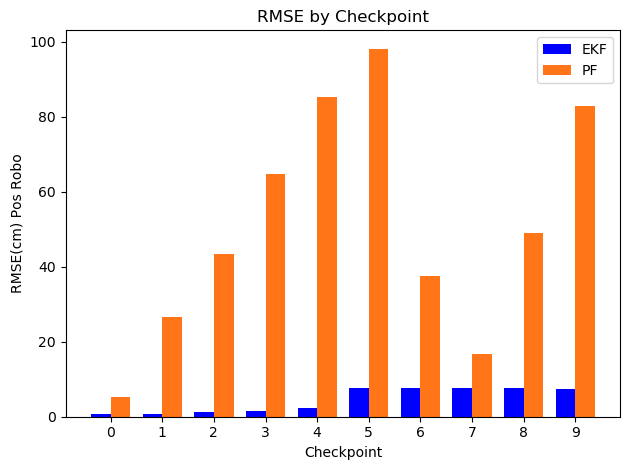

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dados fornecidos (EKF)
ekf_data = [
    (8, 279, 0.076725, 0.010677, 0.077465, 279, 84.025433),
    (5, 478, 0.071595, 0.025839, 0.076115, 478, 79.302797),
    (7, 281, 0.075635, 0.003328, 0.075708, 281, 87.324859),
    (6, 260, 0.074826, 0.011043, 0.075636, 260, 78.319752),
    (9, 773, 0.072025, 0.016667, 0.073928, 773, 81.561087),
    (4, 708, 0.013932, 0.019354, 0.023847, 708, 79.746617),
    (3, 193, 0.005720, 0.015194, 0.016235, 193, 90.800816),
    (2, 199, 0.004987, 0.010528, 0.011650, 199, 82.245237),
    (0, 1240, 0.008160, 0.000867, 0.008206, 1240, 82.439241),
    (1, 202, 0.003576, 0.006139, 0.007104, 202, 81.878983),
]

# Dados fornecidos (PF)
pf_data = [
    (5, 364, 0.980924, 0.026035, 0.981269, 364, 78.506744),
    (4, 414, 0.850070, 0.072289, 0.853138, 414, 80.727916),
    (9, 395, 0.801107, 0.207994, 0.827668, 395, 78.681988),
    (3, 138, 0.640765, 0.083341, 0.646162, 138, 85.972106),
    (8, 169, 0.466866, 0.150950, 0.490662, 169, 87.399518),
    (2, 115, 0.428157, 0.070402, 0.433907, 115, 84.664200),
    (6, 167, 0.371670, 0.053134, 0.375449, 167, 85.115893),
    (1, 119, 0.259372, 0.057728, 0.265718, 119, 81.887977),
    (7, 164, 0.134687, 0.098994, 0.167153, 164, 92.736665),
    (0, 679, 0.049668, 0.019665, 0.053419, 679, 80.421014),
]

cols = ["Checkpoint", "n_pos", "rmse_x", "rmse_y", "rmse_pos2d_m", "n_dist", "rmse_dist"]
ekf = pd.DataFrame(ekf_data, columns=cols)
pf  = pd.DataFrame(pf_data,  columns=cols)

# Converter rmse_pos2d de metros para centímetros
ekf["rmse_pos2d_cm"] = ekf["rmse_pos2d_m"] * 100.0
pf["rmse_pos2d_cm"]  = pf["rmse_pos2d_m"]  * 100.0

# Alinhar checkpoints (merge)
merged = pd.merge(
    ekf[["Checkpoint", "rmse_pos2d_cm"]],
    pf[["Checkpoint", "rmse_pos2d_cm"]],
    on="Checkpoint",
    how="outer",
    suffixes=("_EKF", "_PF"),
).sort_values("Checkpoint").reset_index(drop=True)

print(merged)

# Plot: barras por checkpoint (EKF azul, PF abóbora)
x = np.arange(len(merged["Checkpoint"]))
width = 0.38

plt.figure()
plt.bar(x - width/2, merged["rmse_pos2d_cm_EKF"], width, color="blue", label="EKF")
plt.bar(x + width/2, merged["rmse_pos2d_cm_PF"],  width, color="#FF7518", label="PF")  # abóbora

plt.title("RMSE by Checkpoint")
plt.xlabel("Checkpoint")
plt.ylabel("RMSE(cm) Pos Robo")
plt.xticks(x, merged["Checkpoint"].astype(int))
plt.legend()
plt.tight_layout()
plt.show()